# 08. Optimizare neliniara - Dispatch optim al bateriei (Spania)

**Etapa III: Optimizare neliniara (suport decizional prescriptiv)**

**Scop:** sa transformam **predictiile** de pret (Etapa II) in **decizii concrete**. Stiind cum va evolua pretul energiei, cum operam o baterie ca sa maximizam profitul? Cumparam (incarcam) cand pretul e mic si vindem (descarcam) cand pretul e mare - dar respectand limitele fizice ale bateriei. Aceasta este componenta **prescriptiva** a platformei: nu doar "ce se va intampla", ci "ce ar trebui sa faci".

Folosim seria de preturi a pietei spaniole si un model de optimizare neliniara rezolvat cu SciPy (algoritmul SLSQP).

## Setup

In [1]:
import sys, time
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.optimization.optimizer import (
    BatteryConfig, battery_dispatch_problem, solve_battery_dispatch,
    battery_soc, battery_profit, optimize_nonlinear,
)
from src.utils.plotting import setup_style, PALETA
setup_style()
warnings.filterwarnings("ignore")
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Setup OK.")

Setup OK.


## 1. Ce este optimizarea neliniara (si de ce avem nevoie de ea)

### Problema pe care o rezolvam
Avem o prognoza orara de pret pentru energia electrica. O baterie ne permite sa "mutam" energie in timp: o incarcam acum (consumand din retea) si o descarcam mai tarziu (livrand in retea). Intrebarea prescriptiva este: **cat sa incarcam/descarcam la fiecare ora ca sa castigam maxim**, fara sa stricam bateria si fara sa-i depasim capacitatea?

### Vocabular (definitii simple)
- **Variabile de decizie**: lucrurile pe care le controlam. Aici, `x_t` = puterea la fiecare ora (pozitiv = descarcare/vindem, negativ = incarcare/cumparam).
- **Functie obiectiv**: ce vrem sa maximizam (sau minimizam). Aici, profitul.
- **Constrangeri**: regulile pe care solutia trebuie sa le respecte (limite fizice).
  - **bounds** (limite simple): puterea nu poate depasi `p_max` in niciun sens.
  - **inegalitate**: starea de incarcare (SOC) trebuie sa ramana intre 0 si capacitate.
  - **egalitate**: la final bateria revine la nivelul initial (altfel "profitul" ar veni din golirea ei).

### Liniar vs neliniar
Daca obiectivul si constrangerile ar fi toate functii liniare (linii drepte), am avea o problema de **programare liniara**. Aici, includem un **cost de degradare** proportional cu *patratul* puterii (bateriile se uzeaza mai mult la cicluri agresive si exista pierderi la conversie). Acest termen patratic face obiectivul **neliniar**, deci avem nevoie de un optimizator neliniar.

### SLSQP
Folosim **SLSQP** (Sequential Least Squares Programming) din SciPy: un algoritm care, pornind de la o solutie initiala, face pasi succesivi care imbunatatesc obiectivul respectand constrangerile, pana cand nu mai poate progresa (a gasit un **optim local**; pentru probleme convexe ca a noastra, optimul local este si global).

## 2. Incarcarea semnalului de pret

Folosim ultimele 72 de ore (3 zile) din seria spaniola ca prognoza de pret. Profilul tipic - ieftin noaptea, scump dimineata si seara - este exact ce permite arbitrajul cu bateria. In productie, aceste preturi ar veni de la modelul XGBoost antrenat in Etapa II.

In [2]:
df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "pret_spania_features.parquet")
WINDOW = 72
prices = df["price actual"].iloc[-WINDOW:].values.astype(float)
idx = df.index[-WINDOW:]
print(f"Fereastra: {idx[0]} -> {idx[-1]} ({WINDOW} ore)")
print(f"Pret: min={prices.min():.1f}, mediu={prices.mean():.1f}, max={prices.max():.1f} EUR/MWh")

Fereastra: 2018-12-28 23:00:00 -> 2018-12-31 22:00:00 (72 ore)
Pret: min=54.1, mediu=65.1, max=77.6 EUR/MWh


## 3. Definirea bateriei si a problemei

Alegem o baterie de **10 MWh** capacitate, putere maxima **2.5 MW** pe ora, pornind de la **50%** incarcare. Coeficientul de degradare `lambda` penalizeaza ciclurile agresive (termenul neliniar). Cerem ca bateria sa revina la 50% la final (`cyclic=True`).

In [3]:
cfg = BatteryConfig(capacity=10.0, p_max=2.5, soc_init=0.5, lambda_deg=0.02, cyclic=True)
prob = battery_dispatch_problem(prices, cfg)
print(f"Variabile de decizie: {len(prob['x0'])} (cate una per ora)")
print(f"Bounds pe fiecare x_t: +/- {cfg.p_max} MW")
print(f"Constrangeri: {len(prob['constraints'])} (SOC>=0, SOC<=capacitate, sum(x)=0 ciclic)")

Variabile de decizie: 72 (cate una per ora)
Bounds pe fiecare x_t: +/- 2.5 MW
Constrangeri: 3 (SOC>=0, SOC<=capacitate, sum(x)=0 ciclic)


## 4. Rezolvarea problemei (SLSQP)

In [4]:
t = time.time()
out = solve_battery_dispatch(prices, cfg)
res = out["result"]; pr = out["profit"]; x = out["x"]; soc = out["soc"]
print(f"Optimizare terminata in {time.time()-t:.2f}s")
print(f"Convergenta: {res.success} | iteratii: {res.n_iter} | mesaj: {res.message}")
print(f"\n--- Rezultat economic (72h) ---")
print(f"Venit net din tranzactii (revenue): {pr['revenue']:.2f} EUR")
print(f"Cost degradare/pierderi:            {pr['degradation']:.2f} EUR")
print(f"PROFIT NET:                         {pr['net_profit']:.2f} EUR")
print(f"\nVerificare constrangeri:")
print(f"  SOC in [{soc.min():.2f}, {soc.max():.2f}] MWh (limita 0..{cfg.capacity})")
print(f"  sum(x) = {x.sum():.4f} (trebuie ~0, ciclic)")
print(f"  |x| max = {np.abs(x).max():.2f} MW (limita {cfg.p_max})")

Optimizare terminata in 0.07s
Convergenta: True | iteratii: 12 | mesaj: Optimization terminated successfully

--- Rezultat economic (72h) ---
Venit net din tranzactii (revenue): 566.93 EUR
Cost degradare/pierderi:            5.93 EUR
PROFIT NET:                         561.00 EUR

Verificare constrangeri:
  SOC in [0.00, 10.00] MWh (limita 0..10.0)
  sum(x) = -0.0000 (trebuie ~0, ciclic)
  |x| max = 2.50 MW (limita 2.5)


## 5. Vizualizare: pret, dispatch si stare de incarcare

Graficul de jos arata cum decizia urmeaza pretul: bateria se **incarca** (bare albastre, x<0) in orele ieftine si se **descarca** (bare rosii, x>0) in orele scumpe. SOC-ul (linia neagra) creste la incarcare si scade la descarcare, ramanand mereu in limite.

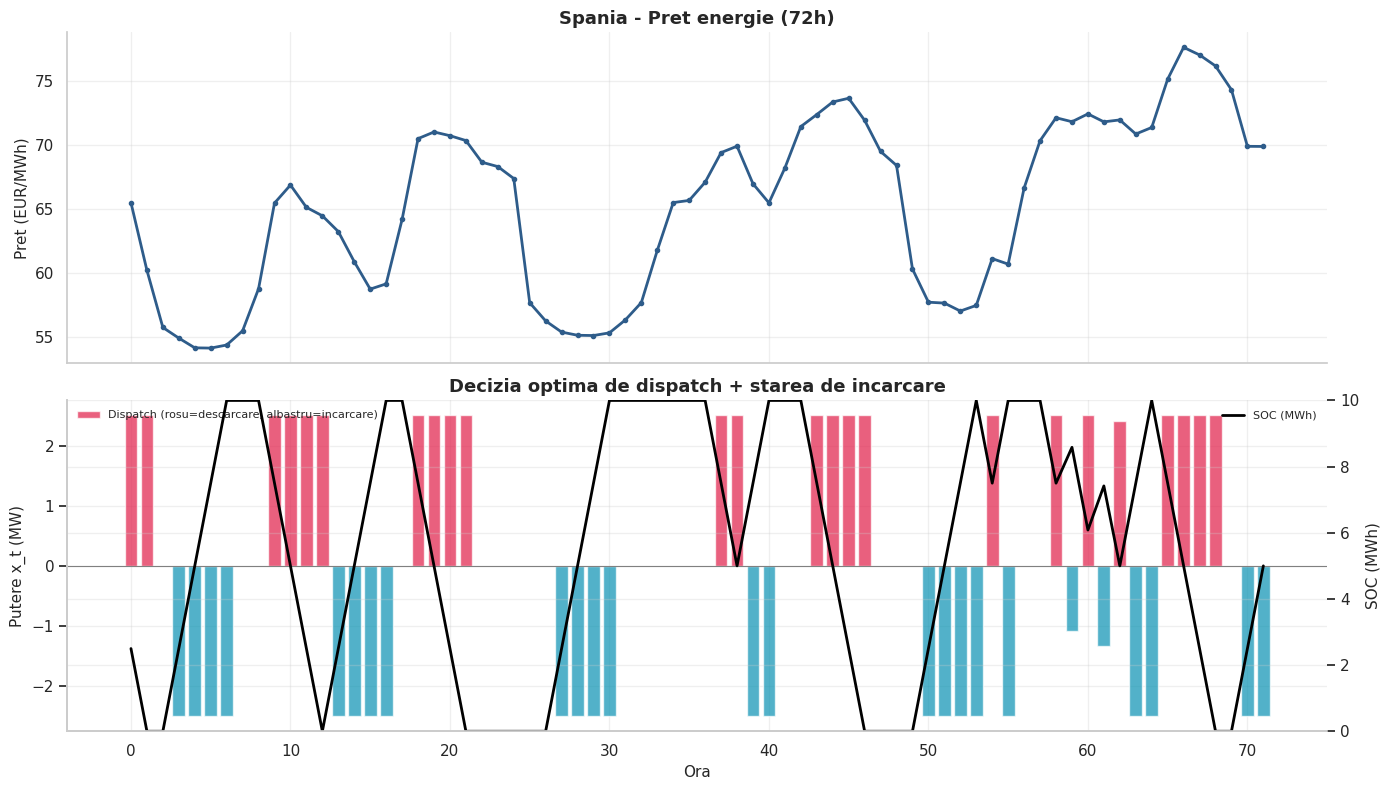

Figura salvata: reports/figures/fig_8_1_dispatch_baterie.png


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
# Sus: pretul
ax1.plot(range(len(prices)), prices, color=PALETA["primary"], lw=2, marker="o", ms=3)
ax1.set_ylabel("Pret (EUR/MWh)"); ax1.set_title("Spania - Pret energie (72h)")
ax1.grid(True, alpha=0.3)
# Jos: dispatch (bare) + SOC (linie)
cols = ["#E11D48" if v > 0 else "#0891B2" for v in x]
ax2.bar(range(len(x)), x, color=cols, alpha=0.7, label="Dispatch (rosu=descarcare, albastru=incarcare)")
ax2.set_ylabel("Putere x_t (MW)"); ax2.axhline(0, color="gray", lw=0.8)
ax2b = ax2.twinx()
ax2b.plot(range(len(soc)), soc, color="black", lw=2, label="SOC (MWh)")
ax2b.set_ylabel("SOC (MWh)"); ax2b.set_ylim(0, cfg.capacity)
ax2.set_xlabel("Ora")
ax2.set_title("Decizia optima de dispatch + starea de incarcare")
ax2.legend(loc="upper left", fontsize=8); ax2b.legend(loc="upper right", fontsize=8)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_8_1_dispatch_baterie.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figura salvata: reports/figures/fig_8_1_dispatch_baterie.png")

## 6. Comparatie cu o strategie naiva (valoarea optimizarii)

Pentru a arata ca optimizarea aduce un castig real, o comparam cu o regula simpla "de bun-simt": incarca la putere maxima in cele mai ieftine ore, descarca la maxim in cele mai scumpe (numar egal de ore, ca sa fie ciclic). Optimizarea ar trebui sa fie cel putin la fel de buna, de obicei mai buna, fiindca distribuie puterea mai inteligent si tine cont de degradare.

In [6]:
def naive_dispatch(prices, cfg, n_hours=18):
    T = len(prices); x = np.zeros(T)
    order = np.argsort(prices)
    charge_h = order[:n_hours]      # cele mai ieftine
    discharge_h = order[-n_hours:]  # cele mai scumpe
    # putere aleasa ca sa nu depaseasca capacitatea utila
    p = min(cfg.p_max, (cfg.capacity * 0.5) / n_hours)
    x[charge_h] = -p; x[discharge_h] = +p
    return x

x_naive = naive_dispatch(prices, cfg)
pr_naive = battery_profit(x_naive, prices, cfg)
soc_naive = battery_soc(x_naive, cfg)
print(f"Strategie NAIVA:    profit net = {pr_naive['net_profit']:.2f} EUR (SOC in [{soc_naive.min():.1f}, {soc_naive.max():.1f}])")
print(f"Optimizare SLSQP:   profit net = {pr['net_profit']:.2f} EUR")
gain = pr['net_profit'] - pr_naive['net_profit']
pct = 100 * gain / abs(pr_naive['net_profit']) if pr_naive['net_profit'] != 0 else float('nan')
print(f"\nCastig din optimizare: +{gain:.2f} EUR ({pct:+.1f}% fata de strategia naiva)")

Strategie NAIVA:    profit net = 85.61 EUR (SOC in [5.0, 8.6])
Optimizare SLSQP:   profit net = 561.00 EUR

Castig din optimizare: +475.39 EUR (+555.3% fata de strategia naiva)


## 7. Analiza de sensibilitate: cum scaleaza profitul cu capacitatea

O intrebare practica pentru un investitor: cat profit aduce o baterie mai mare? Rezolvam problema pentru mai multe capacitati si vedem tendinta. De obicei profitul creste cu capacitatea, dar cu randament descrescator (orele foarte ieftine/scumpe sunt limitate).

 capacitate_MWh  profit_net_EUR  convergenta
            2.5          169.66         True
            5.0          321.40         True
           10.0          561.00         True
           20.0          818.10         True
           40.0          930.95         True


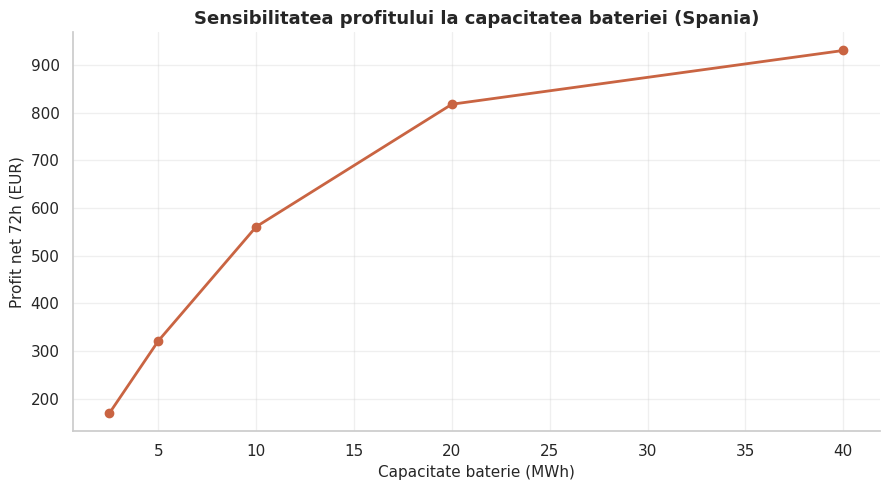

Figura salvata: reports/figures/fig_8_2_sensibilitate_capacitate.png


In [7]:
caps = [2.5, 5, 10, 20, 40]
rows = []
for c in caps:
    cfg_c = BatteryConfig(capacity=c, p_max=cfg.p_max, soc_init=0.5, lambda_deg=cfg.lambda_deg, cyclic=True)
    o = solve_battery_dispatch(prices, cfg_c)
    rows.append({"capacitate_MWh": c, "profit_net_EUR": round(o["profit"]["net_profit"], 2),
                 "convergenta": o["result"].success})
sens = pd.DataFrame(rows)
print(sens.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sens["capacitate_MWh"], sens["profit_net_EUR"], marker="o", color=PALETA["secondary"], lw=2)
ax.set_xlabel("Capacitate baterie (MWh)"); ax.set_ylabel("Profit net 72h (EUR)")
ax.set_title("Sensibilitatea profitului la capacitatea bateriei (Spania)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_8_2_sensibilitate_capacitate.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figura salvata: reports/figures/fig_8_2_sensibilitate_capacitate.png")

## 8. Concluzii

Am demonstrat componenta **prescriptiva** a platformei: pornind de la o prognoza de pret, optimizarea neliniara (SLSQP) produce un plan orar concret de operare a bateriei care maximizeaza profitul respectand toate limitele fizice. Solutia confirma intuitia economica - incarca ieftin, descarca scump - dar o face optim, distribuind puterea mai bine decat o regula naiva si tinand cont de uzura.

Aceasta este legatura directa cu obiectivul lucrarii: modelele predictive (Etapa II) alimenteaza motorul de optimizare (Etapa III), care transforma cunoasterea viitorului in **decizii actionabile**. Urmatorii pasi din aceasta etapa: load shifting pe consumul USA si optimizarea parametrilor fizici pentru productia solara India. Apoi, modulul LLM (Etapa IV) va explica aceste recomandari in limbaj natural, iar aplicatia Streamlit (Etapa V) le va expune interactiv.